## 1. Configuração do ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Carregando o dataset
### Esquema das variáveis conforme o Kaggle
- Customers who left within the last month: the column is called Churn

- Services that each customer has signed up for: phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

- Customer account information: how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

- Demographic info about customers: gender, age range, and if they have partners and dependents

In [8]:
# define o caminho
path = '../../data/raw/ibm-telco-customer-churn.csv'

# carrega os dados
df = pd.read_csv(path)

print(f"Shape dos dados: {df.shape}")
print("\nPrimeiras linhas do dataset:")
df.head()

Shape dos dados: (7043, 21)

Primeiras linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===")
df.info()

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBillin

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Análise Exploratória de Dados (EDA)
### 3.1 Análise de Missing Values
**Objetivo:** Identificar valores ausentes e entender seu padrão de distribuição

In [13]:
print("=== ANÁLISE DE MISSING VALUES ===")

missing_values = pd.DataFrame({
    "Coluna": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values["Missing_Count"] > 0].sort_values(by="Missing_Percentage", ascending=False)

if len(missing_values) > 0:
    print(missing_values)

    plt.figure(figsize=(10,6))
    plt.barh(missing_values["Coluna"], missing_values["Missing_Percentage"], color='coral')
    plt.xlabel('Porcentagem de Valores Ausentes (%)')
    plt.ylabel('Colunas')
    plt.tittle('Porcentagem de Valores Ausentes por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna possui valores ausentes.")

=== ANÁLISE DE MISSING VALUES ===
Nenhuma coluna possui valores ausentes.


### 3.2 Análise da Variável Target
**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===
Contagem de cada classe:
target
0    5174
1    1869
Name: count, dtype: int64

Porcentagem de cada classe:
No Churn: 73.46%
Churn: 26.54%


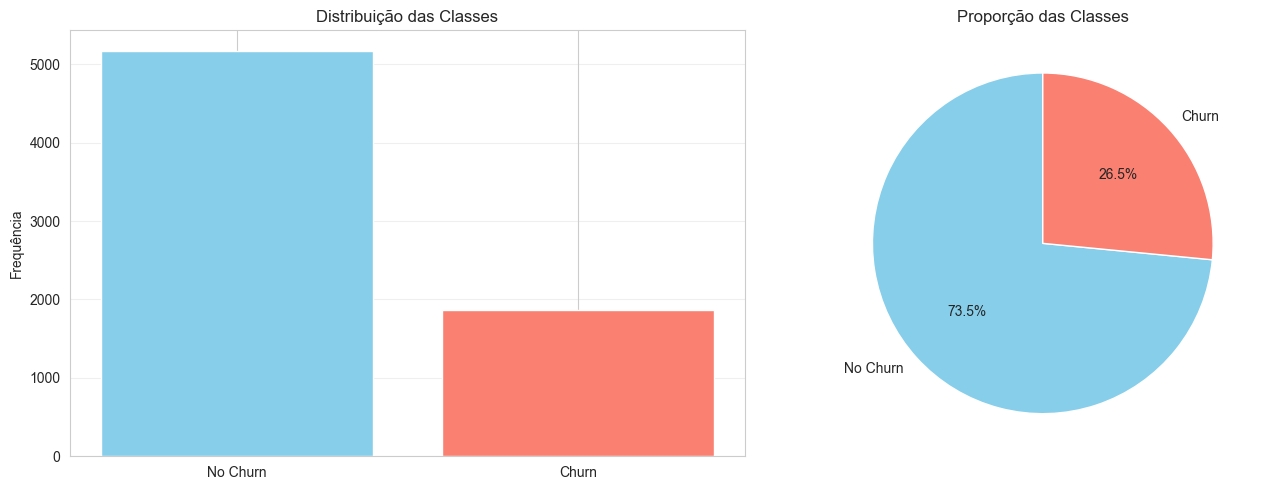


Ratio de desbalanceamento: 0.36
Variável desbalanceada


In [20]:
# renomear a variável target para target
# df.rename(columns={'Churn': 'target'}, inplace=True)

# converter target para binário (Yes = 1, No = 0)
# df['target'] = df['target'].map({'Yes': 1, 'No': 0}).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem de cada classe:")
print(target_counts)
print("\nPorcentagem de cada classe:")
for idx, pct in target_percentages.items():
    label = 'Churn' if idx == 1 else 'No Churn'
    print(f"{label}: {pct:.2f}%")

# vizualização da distribuição da variável target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# grafico de barras
axes[0].bar(["No Churn", "Churn"], target_counts, color=['skyblue', 'salmon'])
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição das Classes")
axes[0].grid(axis='y', alpha=0.3)

# grafico de setores
axes[1].pie(target_counts.values, labels=["No Churn", "Churn"], 
            autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
axes[1].set_title("Proporção das Classes")

plt.tight_layout()
plt.show()

# avaliar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de desbalanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("Variável desbalanceada")
else:
    print("Variável razoavelmente balanceada")

A variável alvo (target) indica se há houve ou não churn. Na visualização, vemos 1869 casos de churn (26,54%) e 5174 no churn (73,46%), o que mostra uma predominância da classe negativa; o ratio entre as classes é de aproximadamente 0,36, indicando um desbalanceamento entre as classes. Isso significa que devemos utilizar a divisão estratificada e técnicas como class_weight ou SMOTE.